
# Comparação de Performance: Dijkstra Clássico vs Dijkstra com Min-Heap



## Objetivo



Avaliar **tempo de execução** e **pegada de carbono (CO₂)** das seguintes abordagens de caminho mínimo:
- **Dijkstra Clássico** (`O(V² + E)`), conforme implementado em sala;
- **Dijkstra com Min-Heap** (`O((V + E) * log V)`), conforme implementado em sala;

> **Obrigatório**: reutilizar as **versões das aulas** (`dijsktra.ipynb` e `dijsktra_min_heap.ipynb`). Ajustes menores são permitidos (p.ex., medições, modularização, execução), sem mudar a lógica.




## Descrição do Problema



Você deverá:
1. Gerar **grafos ponderados e conectados** com o `networkx` em diferentes tamanhos, **indo até 100.000 nós** (ou o máximo suportado pela sua máquina).
2. Para cada grafo, escolher **5 nós aleatórios** e calcular o **caminho mínimo** desses nós para **todos os demais nós** usando:
   - A versão **clássica** de Dijkstra;
   - A versão **com Min-Heap**;
   - A função de **referência** do `networkx`.
3. Repetir o experimento **15 a 20 vezes por tamanho** (trocando os 5 nós a cada repetição) para robustez estatística.
4. Medir e registrar para cada execução:
   - **Tempo** (s);
   - **CO₂** com [CodeCarbon](https://github.com/mlco2/codecarbon).
5. Calcular Intervalos de Confiança para as médias de tempo e CO₂.
6. Gerar **gráficos** e **tabelas** comparativas e **salvá-los no repositório**.





### Configuração Experimental


- Tamanhos sugeridos: `[100, 500, 1_000, 5_000, 10_000, 50_000, 100_000]`.
- **Reprodutibilidade**: fixe sementes (`numpy` e `random`).
- Geração de grafos: `nx.gnp_random_graph(n, p)` com pesos inteiros positivos (ex.: `1..10`).  
  Garanta conectividade (ex.: use o **componente gigante** quando necessário).
- **15–20 repetições** por tamanho; **5 fontes** por repetição.
- Evite travamentos validando primeiro em tamanhos menores.


### Métricas e Estatística



Nesta etapa, você vai transformar os dados brutos coletados (tempos e emissões de CO₂ de cada execução) em informações **estatisticamente interpretáveis**.  
O objetivo é comparar o desempenho dos algoritmos a partir das **médias** e **desvios-padrão** das execuções.


Para cada par **(tamanho do grafo, algoritmo)**, calcule:

| Métrica | Símbolo | Descrição |
|----------|----------|-----------|
| Média | \\(\bar{x}\\) | Tempo médio (ou CO₂ médio) das execuções |
| Desvio-padrão | \\(s\\) | Mede a variação dos resultados em torno da média |


Para cada algoritmo e tamanho de grafo, plote:

- **Eixo X:** número de nós do grafo  
- **Eixo Y:** tempo médio (ou CO₂ médio)  
- **Uma linha para cada algoritmo**  
- **Barras verticais** indicando a variação (\\(\bar{x} \pm s\\))







##Entregáveis




- **Repositório GitHub** contendo:
  - Notebook `.ipynb` com código, análises, **gráficos salvos** (`.png`/`.svg`) e tabelas (`.csv`);
  - `README.md` explicando metodologia, resultados e **link do vídeo**;
  - Vídeo (até 10min) Explique rapidamente os algoritmos, mostre a execução, apresente gráficos e discuta resultados. Sugestão de ferramentas (Loom e Youtube).
  - Organização clara e reprodutível (seções, funções, seeds).




## Avaliação (3 pts – Unidade 2)




| Critério | Descrição | Peso |
|---|---|---|
| Organização e reprodutibilidade | Estrutura limpa, README completo, seeds e scripts | 1.0 |
| Correção e **reutilização** das versões de sala | Aderência às implementações solicitadas | 1.0 |
| Análise e apresentação | Interpretação dos resultados, gráficos e vídeo | 1.0 |

**Individual ou em dupla.**


## Importações e funções genericas

In [1]:
import networkx as nx
import random
import matplotlib.pyplot as plt
import time
from codecarbon import EmissionsTracker
import gc
import os
import pickle  # usamos pickle diretamente

In [2]:
def parse_to_list(edges):
    # Número de nós (pode ser inferido)
    n = max(max(u, v) for u, v, _ in edges) + 1

    # Cria lista de listas vazias
    edges_estruturado = [[] for _ in range(n)]

    # Preenche para grafo não direcionado
    for u, v, data in edges:
        w = data['weight']
        edges_estruturado[u].append([v, w])  # adiciona v na lista de u
        edges_estruturado[v].append([u, w])  # adiciona u na lista de v (não direcionado)

    return edges_estruturado


In [3]:
import networkx as nx
import random
import pickle
import os
import gc

def criar_grafo(len_graph, p=0.01):
    """
    Cria um grafo aleatório ponderado conectado e salva em 'grafos/'.
    """
    # Cria grafo aleatório
    G = nx.gnp_random_graph(len_graph, p=p, seed=22)

    # Garante que o grafo seja conectado: pega o maior componente conectado
    if not nx.is_connected(G):
        largest_cc = max(nx.connected_components(G), key=len)
        G = G.subgraph(largest_cc).copy()
        print(f"⚠ Grafo desconexo: mantendo apenas o maior componente com {len(G)} nós.")

    # Adiciona pesos inteiros entre 1 e 10
    for u, v in G.edges():
        G[u][v]['weight'] = random.randint(1, 10)

    # Garante que a pasta 'grafos' exista
    os.makedirs("grafos", exist_ok=True)

    # Salva o grafo com pickle
    with open(f"grafos/grafo_{len_graph}.gpickle", "wb") as f:
        pickle.dump(G, f)

    print(f"✅ Grafo salvo em 'grafos/grafo_{len_graph}.gpickle'")

    # Libera memória
    del G
    gc.collect()


In [4]:
def ler_grafo(len_graph):
    # Lê o grafo salvo
    with open(f"grafos/grafo_{len_graph}.gpickle", "rb") as f:
        G = pickle.load(f)

    print(f"🔄 Grafo 'grafo_{len_graph}' lido com sucesso ({G.number_of_nodes()} nós, {G.number_of_edges()} arestas)")
    return G

In [5]:
criar_grafo(100)
criar_grafo(500)
criar_grafo(1000)
criar_grafo(5000)
criar_grafo(10000)
criar_grafo(50000)

⚠ Grafo desconexo: mantendo apenas o maior componente com 14 nós.
✅ Grafo salvo em 'grafos/grafo_100.gpickle'
⚠ Grafo desconexo: mantendo apenas o maior componente com 495 nós.
✅ Grafo salvo em 'grafos/grafo_500.gpickle'
✅ Grafo salvo em 'grafos/grafo_1000.gpickle'
✅ Grafo salvo em 'grafos/grafo_5000.gpickle'
✅ Grafo salvo em 'grafos/grafo_10000.gpickle'
✅ Grafo salvo em 'grafos/grafo_50000.gpickle'


In [6]:
import random
import pandas as pd
import networkx as nx
import pickle
import gc

tamanhos = [100, 500, 1000, 5000, 10000, 50000]
n_start = 5
n_repeticoes = 15

starts_for_graph = {}

for tamanho in tamanhos:
    starts_for_graph[f"grafo_{tamanho}"] = []

    # Lê o grafo **uma vez por vez**
    with open(f"grafos/grafo_{tamanho}.gpickle", "rb") as f:
        G = pickle.load(f)

    # Pega os nós realmente existentes
    nodes_list = list(G.nodes())

    for _ in range(n_repeticoes):
        # Sorteia 5 nós existentes
        starts = random.sample(nodes_list, n_start)
        starts_for_graph[f"grafo_{tamanho}"].append(starts)

    print(f"Grafo_{tamanho} OK")
    # Libera memória do grafo antes de passar para o próximo tamanho
    del G
    gc.collect()

# Cria DataFrame e salva
df_start = pd.DataFrame(starts_for_graph)
df_start.to_csv("Starts_for_graph.csv", index=False)
print("✅ DF_starts salvo com segurança!")


Grafo_100 OK
Grafo_500 OK
Grafo_1000 OK
Grafo_5000 OK
Grafo_10000 OK
Grafo_50000 OK
✅ DF_starts salvo com segurança!


In [10]:
import ast
import pandas as pd
# Lê o CSV
df = pd.read_csv("Starts_for_graph.csv")

starts_for_graph = {}

for col in df.columns:
    # Cada célula é uma string, converte para lista usando ast.literal_eval
    starts_for_graph[col] = [ast.literal_eval(cell) for cell in df[col]]

# Teste de visualização
print(starts_for_graph["grafo_100"][0])  # imprime a primeira repetição do grafo_100


[56, 51, 29, 48, 58]


In [11]:
import time
import statistics
import gc

def measure_experiment(n_runs, len_graph):
    """
    Executa o experimento em um mesmo grafo.
    Para cada execução (repetição), pega os 5 nós iniciais correspondentes
    de starts_for_graph e roda o Dijkstra para cada nó.
    Mede o tempo total da execução da repetição e calcula estatísticas.
    """
    times = []
    ctd = 0

    # Lê o grafo uma vez
    G = ler_grafo(len_graph)
    edges_list = parse_to_list(G.edges(data=True))

    del G
    gc.collect()

    print(f"🔹 Executando o experimento {n_runs} vezes, no grafo de ({len_graph} vértices)\n")

    for i in range(n_runs):
        # Para cada repetição, pega os 5 nós correspondentes
        starts = starts_for_graph[f'grafo_{len_graph}'][i]

        start_time = time.time()

        for start_node in starts:
            result = dijkstrasAlgorithm(start_node, edges_list)
            ctd += 1

        end_time = time.time()
        elapsed = end_time - start_time
        times.append(elapsed)

        print(f"Rodada {i+1}/{n_runs}: tempo = {elapsed:.4f}s")

    # Estatísticas finais
    mean_time = statistics.mean(times)
    std_time = statistics.stdev(times)

    print(f"\n📊 Resultados Médios do Experimento (mesmo grafo, {n_runs} rodadas)")
    print(f"Tempo médio: {mean_time:.4f}s ± {std_time:.4f}s")

    del edges_list
    gc.collect()

    return {
        "mean_time": mean_time,
        "std_time": std_time,
        "lista_tempos": times,
        "interações": ctd,
        "len_graph": len_graph
    }


# Dijkstra's Algorithm metrics

In [12]:
# O(V^2 + E) time | O(V) space - where V is the number of vertices and E is the number of edges in the input graph
def dijkstrasAlgorithm(start, edges):
    """
    Implements Dijkstra's algorithm to find the shortest path from a starting node to all other nodes in a graph.
(V + E) * log V
    Args:
        start (int): The starting node index.
        edges (list of list): Adjacency list representing the graph. Each index corresponds to a vertex,
                              and each entry is a list of pairs [destination, weight].

    Returns:
        list: A list of the shortest distances from the starting node to each node. If a node is not reachable,
              the distance is -1.
    """
    numberOfVertices = len(edges)

    # Initialize the minimum distances for all vertices as infinity
    # except the starting vertex which is set to 0.
    minDistances = [float("inf") for _ in range(numberOfVertices)]
    minDistances[start] = 0

    # Keep track of visited nodes to avoid reprocessing them.
    visited = set()

    # Continue processing nodes until all have been visited.
    while len(visited) != numberOfVertices:
        # Find the vertex with the smallest known distance that has not been visited.
        vertex, currentMinDistance = getVertexWithMinDistance(minDistances, visited)

        # If the smallest distance is infinity, all remaining vertices are unreachable.
        if currentMinDistance == float("inf"):
            break

        # Mark the current vertex as visited.
        visited.add(vertex)

        # Iterate through all the neighbors of the current vertex.
        for edge in edges[vertex]:
            destination, distanceToDestination = edge

            # Skip the neighbor if it has already been visited.
            if destination in visited:
                continue

            # Calculate the new potential path distance to the neighbor.
            newPathDistance = currentMinDistance + distanceToDestination
            currentDestinationDistance = minDistances[destination]

            # Update the shortest distance to the neighbor if the new path is shorter.
            if newPathDistance < currentDestinationDistance:
                minDistances[destination] = newPathDistance

    # Replace any remaining infinity distances with -1 to indicate unreachable nodes.
    return list(map(lambda x: -1 if x == float("inf") else x, minDistances))


def getVertexWithMinDistance(distances, visited):
    """
    Helper function to find the vertex with the smallest known distance that has not been visited.

    Args:
        distances (list): A list of the shortest known distances to each vertex.
        visited (set): A set of vertices that have already been visited.

    Returns:
        tuple: The index of the vertex with the smallest distance and its distance value.
    """
    currentMinDistance = float("inf")
    vertex = -1

    # Iterate over all vertices to find the one with the smallest distance.
    for vertexIdx, distance in enumerate(distances):
        # Skip the vertex if it has already been visited.
        if vertexIdx in visited:
            continue

        # Update the current minimum distance and vertex if a smaller distance is found.
        if distance <= currentMinDistance:
            vertex = vertexIdx
            currentMinDistance = distance

    return vertex, currentMinDistance

In [13]:
# Exemplo de uso:
resultados_100 = measure_experiment(15,100)

🔄 Grafo 'grafo_100' lido com sucesso (14 nós, 13 arestas)
🔹 Executando o experimento 15 vezes, no grafo de (100 vértices)

Rodada 1/15: tempo = 0.0005s
Rodada 2/15: tempo = 0.0005s
Rodada 3/15: tempo = 0.0005s
Rodada 4/15: tempo = 0.0005s
Rodada 5/15: tempo = 0.0005s
Rodada 6/15: tempo = 0.0005s
Rodada 7/15: tempo = 0.0005s
Rodada 8/15: tempo = 0.0005s
Rodada 9/15: tempo = 0.0005s
Rodada 10/15: tempo = 0.0005s
Rodada 11/15: tempo = 0.0005s
Rodada 12/15: tempo = 0.0005s
Rodada 13/15: tempo = 0.0005s
Rodada 14/15: tempo = 0.0005s
Rodada 15/15: tempo = 0.0005s

📊 Resultados Médios do Experimento (mesmo grafo, 15 rodadas)
Tempo médio: 0.0005s ± 0.0000s


In [14]:
resultados_500 = measure_experiment(15,500)

🔄 Grafo 'grafo_500' lido com sucesso (495 nós, 1256 arestas)
🔹 Executando o experimento 15 vezes, no grafo de (500 vértices)

Rodada 1/15: tempo = 0.0599s
Rodada 2/15: tempo = 0.0597s
Rodada 3/15: tempo = 0.0599s
Rodada 4/15: tempo = 0.0603s
Rodada 5/15: tempo = 0.0612s
Rodada 6/15: tempo = 0.0601s
Rodada 7/15: tempo = 0.0632s
Rodada 8/15: tempo = 0.0660s
Rodada 9/15: tempo = 0.0636s
Rodada 10/15: tempo = 0.0640s
Rodada 11/15: tempo = 0.0612s
Rodada 12/15: tempo = 0.0642s
Rodada 13/15: tempo = 0.0801s
Rodada 14/15: tempo = 0.0753s
Rodada 15/15: tempo = 0.0718s

📊 Resultados Médios do Experimento (mesmo grafo, 15 rodadas)
Tempo médio: 0.0647s ± 0.0062s


In [15]:
resultados_1000 = measure_experiment(15,1000)

🔄 Grafo 'grafo_1000' lido com sucesso (1000 nós, 5033 arestas)
🔹 Executando o experimento 15 vezes, no grafo de (1000 vértices)

Rodada 1/15: tempo = 0.2434s
Rodada 2/15: tempo = 0.2462s
Rodada 3/15: tempo = 0.2557s
Rodada 4/15: tempo = 0.2529s
Rodada 5/15: tempo = 0.3053s
Rodada 6/15: tempo = 0.3143s
Rodada 7/15: tempo = 0.3114s
Rodada 8/15: tempo = 0.2828s
Rodada 9/15: tempo = 0.2497s
Rodada 10/15: tempo = 0.2451s
Rodada 11/15: tempo = 0.2464s
Rodada 12/15: tempo = 0.2850s
Rodada 13/15: tempo = 0.2464s
Rodada 14/15: tempo = 0.2464s
Rodada 15/15: tempo = 0.2386s

📊 Resultados Médios do Experimento (mesmo grafo, 15 rodadas)
Tempo médio: 0.2646s ± 0.0272s


In [16]:
resultados_5000 = measure_experiment(15,5000)

🔄 Grafo 'grafo_5000' lido com sucesso (5000 nós, 125222 arestas)
🔹 Executando o experimento 15 vezes, no grafo de (5000 vértices)

Rodada 1/15: tempo = 6.0790s
Rodada 2/15: tempo = 6.1324s
Rodada 3/15: tempo = 6.0847s
Rodada 4/15: tempo = 6.0928s
Rodada 5/15: tempo = 6.1163s
Rodada 6/15: tempo = 6.0813s
Rodada 7/15: tempo = 6.0569s
Rodada 8/15: tempo = 6.0700s
Rodada 9/15: tempo = 6.1025s
Rodada 10/15: tempo = 6.0734s
Rodada 11/15: tempo = 6.4884s
Rodada 12/15: tempo = 6.1418s
Rodada 13/15: tempo = 6.0301s
Rodada 14/15: tempo = 5.9958s
Rodada 15/15: tempo = 6.0684s

📊 Resultados Médios do Experimento (mesmo grafo, 15 rodadas)
Tempo médio: 6.1076s ± 0.1116s


In [17]:
resultados_10000 = measure_experiment(15,10000)

🔄 Grafo 'grafo_10000' lido com sucesso (10000 nós, 500227 arestas)
🔹 Executando o experimento 15 vezes, no grafo de (10000 vértices)

Rodada 1/15: tempo = 24.5145s
Rodada 2/15: tempo = 25.1705s
Rodada 3/15: tempo = 24.7531s
Rodada 4/15: tempo = 24.2836s
Rodada 5/15: tempo = 24.1060s
Rodada 6/15: tempo = 24.2551s
Rodada 7/15: tempo = 24.1401s
Rodada 8/15: tempo = 24.2033s
Rodada 9/15: tempo = 24.2994s
Rodada 10/15: tempo = 24.2167s
Rodada 11/15: tempo = 24.0974s
Rodada 12/15: tempo = 24.3893s
Rodada 13/15: tempo = 28.4314s
Rodada 14/15: tempo = 24.7882s
Rodada 15/15: tempo = 24.4727s

📊 Resultados Médios do Experimento (mesmo grafo, 15 rodadas)
Tempo médio: 24.6747s ± 1.0813s


In [18]:
resultados_50000 = measure_experiment(15,50000)

🔄 Grafo 'grafo_50000' lido com sucesso (50000 nós, 12501473 arestas)
🔹 Executando o experimento 15 vezes, no grafo de (50000 vértices)

Rodada 1/15: tempo = 660.2910s
Rodada 2/15: tempo = 690.0284s
Rodada 3/15: tempo = 644.6071s
Rodada 4/15: tempo = 652.4277s
Rodada 5/15: tempo = 699.9958s
Rodada 6/15: tempo = 710.1855s
Rodada 7/15: tempo = 727.5085s
Rodada 8/15: tempo = 709.7596s
Rodada 9/15: tempo = 705.6494s
Rodada 10/15: tempo = 676.1406s
Rodada 11/15: tempo = 689.7489s
Rodada 12/15: tempo = 666.2118s
Rodada 13/15: tempo = 637.2512s
Rodada 14/15: tempo = 683.0080s
Rodada 15/15: tempo = 677.5757s

📊 Resultados Médios do Experimento (mesmo grafo, 15 rodadas)
Tempo médio: 682.0259s ± 26.3145s


In [20]:
import pandas as pd
df = pd.DataFrame([resultados_100,resultados_500,resultados_1000,resultados_5000,resultados_10000,resultados_50000])
df.to_csv("tabelas/Resultados_dijkstra_classico.csv",index=False)

# Dijstrak_min_heap Metrics

In [5]:
class MinHeap:
    """
    MinHeap class: Implements a MinHeap data structure to efficiently manage vertices and their distances
    for algorithms like Dijkstra. This implementation keeps track of the position of each vertex using
    a vertex map for constant-time lookups and updates.
    """
    def __init__(self, array):
        """
        Initializes the MinHeap with an input array of (vertex, distance) pairs.

        Args:
            array (list): List of tuples where each tuple is (vertex, distance).
                          The distance is typically initialized to infinity except for the starting vertex.

        Attributes:
            vertexMap (dict): Maps each vertex to its position in the heap for quick access.
            heap (list): List representing the binary heap as an array.
        """
        # Create a vertex map: Maps vertices to their indices in the heap.
        self.vertexMap = {idx: idx for idx in range(len(array))}

        # Build the heap from the input array to satisfy the heap property.
        self.heap = self.buildHeap(array)

    def isEmpty(self):
        """
        Checks if the heap is empty.

        Returns:
            bool: True if the heap is empty, False otherwise.
        """
        return len(self.heap) == 0

    def buildHeap(self, array):
        """
        Builds the heap from an input array in O(n) time.

        Args:
            array (list): List of (vertex, distance) pairs.

        Returns:
            list: The input array transformed into a valid MinHeap.
        """
        # Start from the first parent node and sift down each node.
        firstParentIdx = (len(array) - 2) // 2
        for currentIdx in reversed(range(firstParentIdx + 1)):
            self.siftDown(currentIdx, len(array) - 1, array)
        return array

    def siftDown(self, currentIdx, endIdx, heap):
        """
        Restores the heap property by "sifting down" a node into its correct position.

        Args:
            currentIdx (int): Index of the node to sift down.
            endIdx (int): Last index in the heap.
            heap (list): The heap array.

        Complexity:
            Time: O(log(n))
            Space: O(1)
        """
        childOneIdx = currentIdx * 2 + 1  # Index of the first child
        while childOneIdx <= endIdx:
            # Determine the index of the second child
            childTwoIdx = currentIdx * 2 + 2 if currentIdx * 2 + 2 <= endIdx else -1

            # Choose the smaller child to maintain the min-heap property
            if childTwoIdx != -1 and heap[childTwoIdx][1] < heap[childOneIdx][1]:
                idxToSwap = childTwoIdx
            else:
                idxToSwap = childOneIdx

            # Swap if the child is smaller than the current node
            if heap[idxToSwap][1] < heap[currentIdx][1]:
                self.swap(currentIdx, idxToSwap, heap)
                currentIdx = idxToSwap  # Move to the swapped position
                childOneIdx = currentIdx * 2 + 1  # Update the first child index
            else:
                return

    def siftUp(self, currentIdx, heap):
        """
        Restores the heap property by "sifting up" a node into its correct position.

        Args:
            currentIdx (int): Index of the node to sift up.
            heap (list): The heap array.

        Complexity:
            Time: O(log(n))
            Space: O(1)
        """
        parentIdx = (currentIdx - 1) // 2  # Calculate parent index
        while currentIdx > 0 and heap[currentIdx][1] < heap[parentIdx][1]:
            self.swap(currentIdx, parentIdx, heap)  # Swap with parent
            currentIdx = parentIdx  # Move to the parent's position
            parentIdx = (currentIdx - 1) // 2

    def remove(self):
        """
        Removes and returns the smallest element (root) in the heap.

        Returns:
            tuple: The (vertex, distance) pair with the smallest distance.

        Complexity:
            Time: O(log(n))
            Space: O(1)
        """
        if self.isEmpty():
            return None

        # Swap the root with the last element and remove it
        self.swap(0, len(self.heap) - 1, self.heap)
        vertex, distance = self.heap.pop()
        self.vertexMap.pop(vertex)  # Remove the vertex from the map

        # Restore the heap property
        self.siftDown(0, len(self.heap) - 1, self.heap)
        return vertex, distance

    def swap(self, i, j, heap):
        """
        Swaps two nodes in the heap and updates their positions in the vertexMap.

        Args:
            i (int): Index of the first node.
            j (int): Index of the second node.
            heap (list): The heap array.
        """
        self.vertexMap[heap[i][0]] = j  # Update vertexMap for heap[i]
        self.vertexMap[heap[j][0]] = i  # Update vertexMap for heap[j]
        heap[i], heap[j] = heap[j], heap[i]  # Swap the nodes in the heap

    def update(self, vertex, value):
        """
        Updates the distance of a given vertex and restores the heap property.

        Args:
            vertex (int): The vertex whose distance is to be updated.
            value (int): The new distance value.

        Complexity:
            Time: O(log(n))
            Space: O(1)
        """
        # Update the heap with the new (vertex, value) pair
        self.heap[self.vertexMap[vertex]] = (vertex, value)
        # Restore the heap property by sifting up the updated node
        self.siftUp(self.vertexMap[vertex], self.heap)

In [6]:
# O((v + e) * log(v)) time | O(v) space — where v is the number
# of vertices and e is the number of edges in the input graph
def dijkstrasAlgorithm(start, edges):
    """
    Implements Dijkstra's algorithm to find the shortest paths from a starting vertex to all other vertices
    in a weighted graph. The graph is represented using an adjacency list.

    Args:
        start (int): The starting vertex index.
        edges (list of list): An adjacency list where each index represents a vertex, and each entry
                              is a list of [destination, weight] pairs.

    Returns:
        list: A list of minimum distances from the starting vertex to each vertex in the graph.
              If a vertex is unreachable, its distance is represented as -1.
    """
    # Step 1: Initialize the number of vertices in the graph
    numberOfVertices = len(edges)

    # Step 2: Initialize the minimum distances with infinity
    # Set the starting vertex's distance to 0
    minDistances = [float("inf") for _ in range(numberOfVertices)]
    minDistances[start] = 0

    # Step 3: Initialize the MinHeap to track the vertices and their current shortest distances
    minDistancesHeap = MinHeap([(idx, float("inf")) for idx in range(numberOfVertices)])
    minDistancesHeap.update(start, 0)  # Update the starting vertex's distance to 0

    # Step 4: Process vertices until the heap is empty
    while not minDistancesHeap.isEmpty():
        # Extract the vertex with the smallest known distance
        vertex, currentMinDistance = minDistancesHeap.remove()

        # If the current distance is infinity, no further reachable vertices exist
        if currentMinDistance == float("inf"):
            break

        # Step 5: Relaxation - Update distances for all neighboring vertices
        for edge in edges[vertex]:
            destination, distanceToDestination = edge  # Extract neighbor and weight

            # Calculate the new potential path distance
            newPathDistance = currentMinDistance + distanceToDestination
            currentDestinationDistance = minDistances[destination]

            # If the new path is shorter, update the distance and the heap
            if newPathDistance < currentDestinationDistance:
                minDistances[destination] = newPathDistance
                minDistancesHeap.update(destination, newPathDistance)

    # Step 6: Convert unreachable vertices' distances from infinity to -1
    return list(map(lambda x: -1 if x == float("inf") else x, minDistances))

In [7]:
start = 0
edges = [
    [[1, 7]],
    [[2, 6], [3, 20], [4, 3]],
    [[3, 14]],
    [[4, 2]],
    [],
    [],
]

In [9]:
resultados_100 = measure_experiment(15,100,5)

[codecarbon WARNING @ 14:20:25] Multiple instances of codecarbon are allowed to run at the same time.


🔹 Executando o experimento 15 vezes, com 5 nós por rodada no mesmo grafo (100 vértices)

Rodada 1/15: tempo = 0.0005s | emissões = 0.000000 kg CO₂
Rodada 2/15: tempo = 0.0005s | emissões = 0.000000 kg CO₂
Rodada 3/15: tempo = 0.0012s | emissões = 0.000000 kg CO₂
Rodada 4/15: tempo = 0.0006s | emissões = 0.000000 kg CO₂
Rodada 5/15: tempo = 0.0005s | emissões = 0.000000 kg CO₂
Rodada 6/15: tempo = 0.0006s | emissões = 0.000000 kg CO₂
Rodada 7/15: tempo = 0.0011s | emissões = 0.000000 kg CO₂
Rodada 8/15: tempo = 0.0008s | emissões = 0.000000 kg CO₂
Rodada 9/15: tempo = 0.0008s | emissões = 0.000000 kg CO₂
Rodada 10/15: tempo = 0.0011s | emissões = 0.000000 kg CO₂
Rodada 11/15: tempo = 0.0009s | emissões = 0.000000 kg CO₂
Rodada 12/15: tempo = 0.0010s | emissões = 0.000000 kg CO₂
Rodada 13/15: tempo = 0.0006s | emissões = 0.000000 kg CO₂
Rodada 14/15: tempo = 0.0013s | emissões = 0.000000 kg CO₂
Rodada 15/15: tempo = 0.0013s | emissões = 0.000000 kg CO₂

📊 Resultados Médios do Experimento

In [10]:
resultados_500 = measure_experiment(15,500,5)

🔹 Executando o experimento 15 vezes, com 5 nós por rodada no mesmo grafo (500 vértices)

Rodada 1/15: tempo = 0.0131s | emissões = 0.000000 kg CO₂
Rodada 2/15: tempo = 0.0117s | emissões = 0.000000 kg CO₂
Rodada 3/15: tempo = 0.0129s | emissões = 0.000000 kg CO₂
Rodada 4/15: tempo = 0.0133s | emissões = 0.000000 kg CO₂
Rodada 5/15: tempo = 0.0119s | emissões = 0.000000 kg CO₂
Rodada 6/15: tempo = 0.0115s | emissões = 0.000000 kg CO₂
Rodada 7/15: tempo = 0.0150s | emissões = 0.000000 kg CO₂
Rodada 8/15: tempo = 0.0245s | emissões = 0.000000 kg CO₂
Rodada 9/15: tempo = 0.0150s | emissões = 0.000000 kg CO₂
Rodada 10/15: tempo = 0.0260s | emissões = 0.000000 kg CO₂
Rodada 11/15: tempo = 0.0112s | emissões = 0.000000 kg CO₂
Rodada 12/15: tempo = 0.0118s | emissões = 0.000000 kg CO₂
Rodada 13/15: tempo = 0.0117s | emissões = 0.000000 kg CO₂
Rodada 14/15: tempo = 0.0119s | emissões = 0.000000 kg CO₂
Rodada 15/15: tempo = 0.0164s | emissões = 0.000000 kg CO₂

📊 Resultados Médios do Experimento

In [11]:
resultados_1000 = measure_experiment(15,1000,5)

🔹 Executando o experimento 15 vezes, com 5 nós por rodada no mesmo grafo (1000 vértices)

Rodada 1/15: tempo = 0.0330s | emissões = 0.000000 kg CO₂
Rodada 2/15: tempo = 0.0278s | emissões = 0.000000 kg CO₂
Rodada 3/15: tempo = 0.0277s | emissões = 0.000000 kg CO₂
Rodada 4/15: tempo = 0.0299s | emissões = 0.000000 kg CO₂
Rodada 5/15: tempo = 0.0285s | emissões = 0.000000 kg CO₂
Rodada 6/15: tempo = 0.0295s | emissões = 0.000000 kg CO₂
Rodada 7/15: tempo = 0.0284s | emissões = 0.000000 kg CO₂
Rodada 8/15: tempo = 0.0275s | emissões = 0.000000 kg CO₂
Rodada 9/15: tempo = 0.0463s | emissões = 0.000000 kg CO₂
Rodada 10/15: tempo = 0.0310s | emissões = 0.000000 kg CO₂
Rodada 11/15: tempo = 0.0593s | emissões = 0.000000 kg CO₂
Rodada 12/15: tempo = 0.0514s | emissões = 0.000000 kg CO₂
Rodada 13/15: tempo = 0.0363s | emissões = 0.000000 kg CO₂
Rodada 14/15: tempo = 0.0370s | emissões = 0.000000 kg CO₂
Rodada 15/15: tempo = 0.0287s | emissões = 0.000000 kg CO₂

📊 Resultados Médios do Experiment

In [12]:
resultados_5000 = measure_experiment(15,5000,5)

🔹 Executando o experimento 15 vezes, com 5 nós por rodada no mesmo grafo (5000 vértices)

Rodada 1/15: tempo = 0.4671s | emissões = 0.000000 kg CO₂
Rodada 2/15: tempo = 0.4853s | emissões = 0.000000 kg CO₂
Rodada 3/15: tempo = 0.4357s | emissões = 0.000000 kg CO₂
Rodada 4/15: tempo = 0.4672s | emissões = 0.000000 kg CO₂
Rodada 5/15: tempo = 0.5167s | emissões = 0.000000 kg CO₂
Rodada 6/15: tempo = 0.5270s | emissões = 0.000000 kg CO₂
Rodada 7/15: tempo = 0.4379s | emissões = 0.000000 kg CO₂
Rodada 8/15: tempo = 0.4427s | emissões = 0.000000 kg CO₂
Rodada 9/15: tempo = 0.4477s | emissões = 0.000000 kg CO₂
Rodada 10/15: tempo = 0.5230s | emissões = 0.000000 kg CO₂
Rodada 11/15: tempo = 0.7646s | emissões = 0.000000 kg CO₂
Rodada 12/15: tempo = 0.4369s | emissões = 0.000000 kg CO₂
Rodada 13/15: tempo = 0.4529s | emissões = 0.000000 kg CO₂
Rodada 14/15: tempo = 0.4885s | emissões = 0.000000 kg CO₂
Rodada 15/15: tempo = 0.4617s | emissões = 0.000000 kg CO₂

📊 Resultados Médios do Experiment

In [13]:
resultados_10000 = measure_experiment(15,10000,5)

🔹 Executando o experimento 15 vezes, com 5 nós por rodada no mesmo grafo (10000 vértices)

Rodada 1/15: tempo = 1.4976s | emissões = 0.000001 kg CO₂
Rodada 2/15: tempo = 1.5634s | emissões = 0.000001 kg CO₂
Rodada 3/15: tempo = 1.3120s | emissões = 0.000001 kg CO₂
Rodada 4/15: tempo = 1.7375s | emissões = 0.000001 kg CO₂
Rodada 5/15: tempo = 1.8124s | emissões = 0.000001 kg CO₂
Rodada 6/15: tempo = 1.7945s | emissões = 0.000001 kg CO₂
Rodada 7/15: tempo = 1.7432s | emissões = 0.000001 kg CO₂
Rodada 8/15: tempo = 1.7324s | emissões = 0.000001 kg CO₂
Rodada 9/15: tempo = 1.7812s | emissões = 0.000001 kg CO₂
Rodada 10/15: tempo = 1.8122s | emissões = 0.000001 kg CO₂
Rodada 11/15: tempo = 1.7600s | emissões = 0.000001 kg CO₂
Rodada 12/15: tempo = 1.7411s | emissões = 0.000001 kg CO₂
Rodada 13/15: tempo = 1.7950s | emissões = 0.000001 kg CO₂
Rodada 14/15: tempo = 2.2117s | emissões = 0.000001 kg CO₂
Rodada 15/15: tempo = 1.7606s | emissões = 0.000001 kg CO₂

📊 Resultados Médios do Experimen

In [14]:
resultados_50000 = measure_experiment(15,50000,5)

🔹 Executando o experimento 15 vezes, com 5 nós por rodada no mesmo grafo (50000 vértices)

Rodada 1/15: tempo = 47.0911s | emissões = 0.000015 kg CO₂
Rodada 2/15: tempo = 47.4310s | emissões = 0.000015 kg CO₂
Rodada 3/15: tempo = 48.1541s | emissões = 0.000015 kg CO₂
Rodada 4/15: tempo = 45.7313s | emissões = 0.000014 kg CO₂
Rodada 5/15: tempo = 47.0886s | emissões = 0.000015 kg CO₂
Rodada 6/15: tempo = 46.0094s | emissões = 0.000014 kg CO₂
Rodada 7/15: tempo = 49.5449s | emissões = 0.000015 kg CO₂
Rodada 8/15: tempo = 49.8674s | emissões = 0.000016 kg CO₂
Rodada 9/15: tempo = 46.0900s | emissões = 0.000014 kg CO₂
Rodada 10/15: tempo = 47.2150s | emissões = 0.000015 kg CO₂
Rodada 11/15: tempo = 44.6064s | emissões = 0.000014 kg CO₂
Rodada 12/15: tempo = 46.5837s | emissões = 0.000014 kg CO₂
Rodada 13/15: tempo = 46.2310s | emissões = 0.000014 kg CO₂
Rodada 14/15: tempo = 46.5272s | emissões = 0.000014 kg CO₂
Rodada 15/15: tempo = 45.2197s | emissões = 0.000018 kg CO₂

📊 Resultados Médi

In [ ]:
resultados_80000 = measure_experiment(15,80000,5)

In [ ]:
import pandas as pd

df = pd.DataFrame([resultados_100,resultados_500,resultados_1000,resultados_5000,resultados_10000,resultados_50000])
df.to_csv("Resultado_Dijstrka_min_heap.csv",index=False)

# Implementação do NetworkX

In [ ]:
import time
import statistics
import gc
import networkx as nx

def measure_experiment_nx(n_runs, len_graph):
    """
    Executa o experimento usando o Dijkstra do NetworkX.
    Para cada execução (repetição), pega os 5 nós iniciais correspondentes
    de starts_for_graph e roda o Dijkstra para cada nó.
    Mede o tempo total da execução da repetição e calcula estatísticas.
    """
    times = []
    ctd = 0

    # Lê o grafo uma vez
    G = ler_grafo(len_graph)  # supondo que ler_grafo retorna um networkx.Graph

    print(f"🔹 Executando o experimento {n_runs} vezes, no grafo de ({len_graph} vértices)\n")

    for i in range(n_runs):
        # Para cada repetição, pega os 5 nós correspondentes
        starts = starts_for_graph[f'grafo_{len_graph}'][i]

        start_time = time.time()

        for start_node in starts:
            # Executa Dijkstra do NetworkX a partir do nó start_node
            distances, paths = nx.single_source_dijkstra(G, source=start_node, weight='weight')
            ctd += 1

        end_time = time.time()
        elapsed = end_time - start_time
        times.append(elapsed)

        print(f"Rodada {i+1}/{n_runs}: tempo = {elapsed:.4f}s")

    # Estatísticas finais
    mean_time = statistics.mean(times)
    std_time = statistics.stdev(times) if n_runs > 1 else 0.0

    print(f"\n📊 Resultados Médios do Experimento (mesmo grafo, {n_runs} rodadas)")
    print(f"Tempo médio: {mean_time:.4f}s ± {std_time:.4f}s")

    # Limpeza de memória
    del G
    gc.collect()

    return {
        "mean_time": mean_time,
        "std_time": std_time,
        "lista_tempos": times,
        "interações": ctd,
        "len_graph": len_graph
    }


In [ ]:
resultados_100 = measure_experiment_nx(15,100)

In [ ]:
resultados_500 = measure_experiment_nx(15,500)

In [ ]:
resultados_1000 = measure_experiment_nx(15,1000)

In [ ]:
resultados_5000 = measure_experiment_nx(15,5000)

In [ ]:
resultados_10000 = measure_experiment_nx(15,10000)

In [ ]:
resultados_50000 = measure_experiment_nx(15,50000)

In [ ]:
import pandas as pd

df = pd.DataFrame([resultados_100,resultados_500,resultados_1000,resultados_5000,resultados_10000,resultados_50000])
df.to_csv("Resultado_Dijstrka_networkX.csv",index=False)

# Gráficos

In [27]:
import matplotlib.pyplot as plt
import os

def plot_comparison(df_list, labels, y_label="Tempo médio (s)", title="Comparação de Algoritmos Dijkstra",
                    marker_size=8, err_scale=1.2, figsize=(10,6), colors=None, save_path="graficos/comparison.png"):
    """
    Plota gráficos comparativos para diferentes algoritmos, apenas pontos e barras de erro com cores diferentes,
    e salva automaticamente em PNG na pasta especificada.
    """
    # Cria a pasta se não existir
    folder = os.path.dirname(save_path)
    if folder and not os.path.exists(folder):
        os.makedirs(folder)

    plt.figure(figsize=figsize)

    # Se não passar cores, usa cores padrão do matplotlib
    if colors is None:
        colors = plt.cm.tab10.colors  # 10 cores padrão

    for i, (df, label) in enumerate(zip(df_list, labels)):
        df_sorted = df.sort_values(by="len_graph")
        x = df_sorted["len_graph"]
        y = df_sorted["mean_time"]
        yerr = df_sorted["std_time"] * err_scale

        color = colors[i % len(colors)]
        plt.errorbar(
            x, y, yerr=yerr,
            capsize=5, marker='o', linestyle='None',
            markersize=marker_size,
            ecolor=color, elinewidth=1.5, markerfacecolor=color, label=label
        )

    plt.xlabel("Número de nós do grafo", fontsize=12)
    plt.ylabel(y_label, fontsize=12)
    plt.title(title, fontsize=14)
    plt.legend(fontsize=10)
    plt.xticks(fontsize=10)
    plt.yticks(fontsize=10)
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.tight_layout()

    # Salva em PNG
    plt.savefig(save_path)
    print(f"Gráfico salvo em: {save_path}")

    plt.show()


In [36]:
import matplotlib.pyplot as plt
import os

def plot_single_algorithm(df, algoritmo_name,color, y_label="Tempo médio (s)", title=None, scale_factor=1.2, save_path=None,
                          figsize=(10,6), marker_size=8, err_linewidth=1.5, font_size=12):
    """
    Plota o desempenho de um único algoritmo com barras de erro indicando desvio padrão.
    Ajustado para tamanho similar aos gráficos comparativos.
    Salva na mesma pasta do script se save_path for fornecido.
    """
    df_sorted = df.sort_values(by="len_graph")
    x = df_sorted["len_graph"]
    y = df_sorted["mean_time"]
    yerr = df_sorted["std_time"] * scale_factor

    plt.figure(figsize=figsize)
    plt.errorbar(
        x, y, yerr=yerr,
        capsize=5, marker='o', linestyle='None',
        ecolor=color, elinewidth=err_linewidth, markerfacecolor=color, markersize=marker_size
    )
    
    plt.xlabel("Número de nós do grafo", fontsize=font_size)
    plt.ylabel(y_label, fontsize=font_size)
    plt.title(title if title else f"Desempenho do {algoritmo_name}", fontsize=font_size+2)
    plt.xticks(fontsize=font_size)
    plt.yticks(fontsize=font_size)
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.tight_layout()

    # Salva na mesma pasta se save_path for fornecido
    if save_path:
        plt.savefig(save_path)
        print(f"Gráfico salvo em: {save_path}")

    plt.show()


In [23]:
df_classic = pd.read_csv("tabelas/Resultados_dijkstra_classico.csv")
df_min_heap = pd.read_csv("tabelas/Resultado_Dijstrka_min_heap.csv")
df_networkx = pd.read_csv("tabelas/Resultado_Dijstrka_networkX.csv")

Gráfico salvo em: graficos/comparison.png


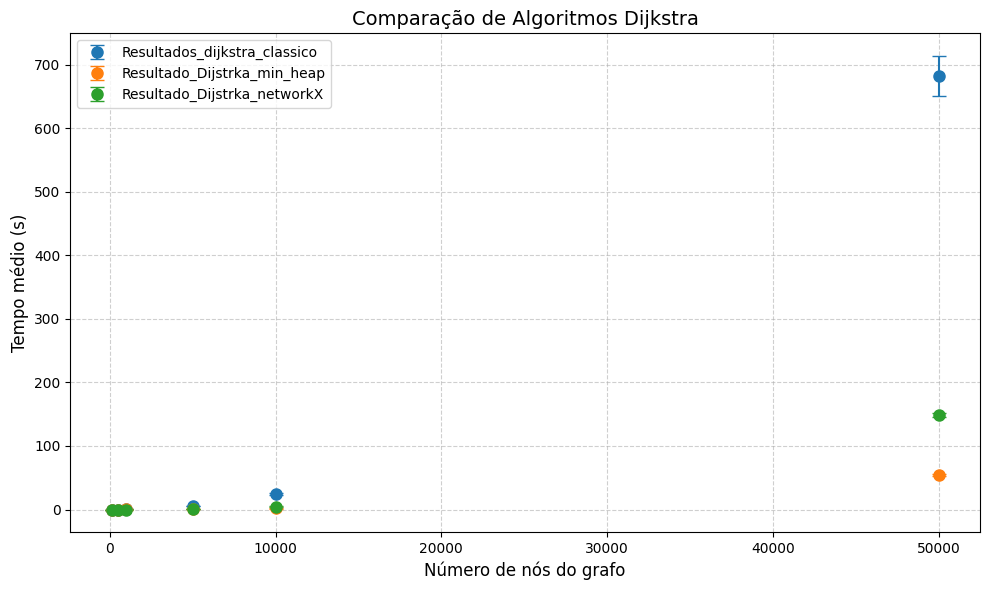

In [28]:
plot_comparison([df_classic,df_min_heap,df_networkx],["Resultados_dijkstra_classico","Resultado_Dijstrka_min_heap","Resultado_Dijstrka_networkX"])

Gráfico salvo em: graficos/Resultados_dijkstra_classico.png


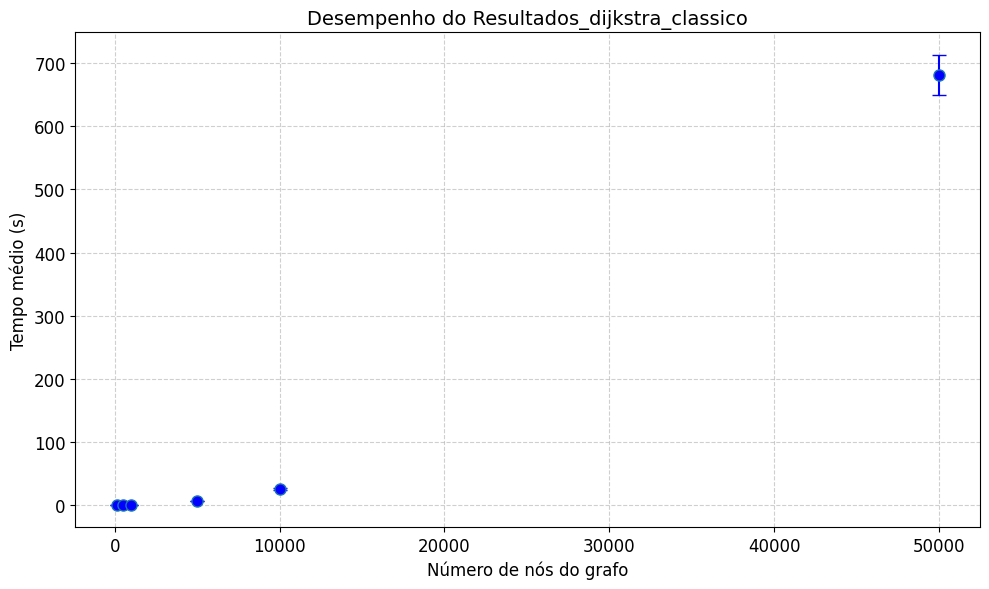

In [39]:
plot_single_algorithm(df_classic,"Resultados_dijkstra_classico","blue",save_path="graficos/Resultados_dijkstra_classico.png")

Gráfico salvo em: graficos/Resultado_Dijstrka_min_heap.png


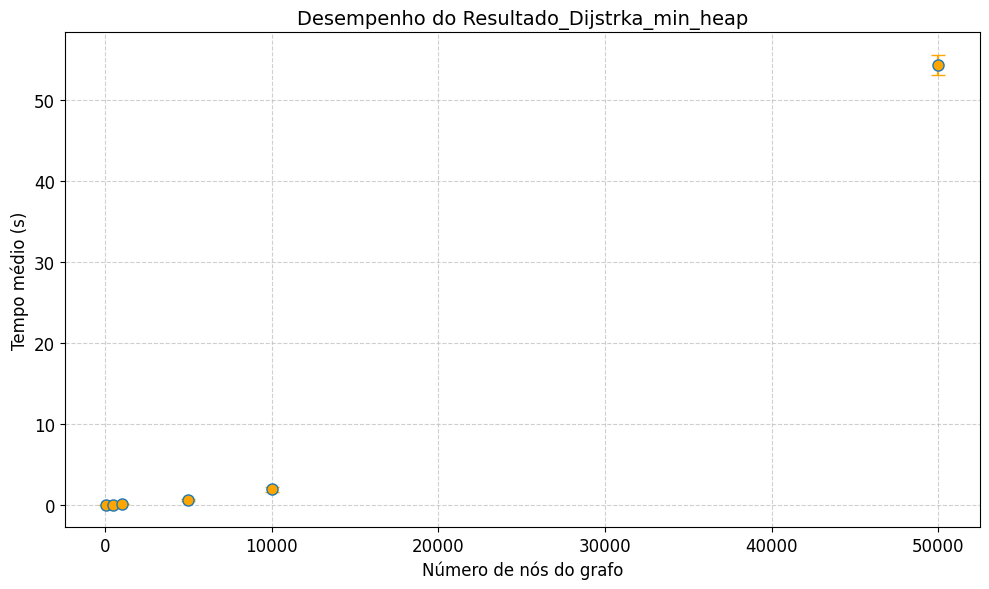

In [41]:
plot_single_algorithm(df_min_heap,"Resultado_Dijstrka_min_heap","orange",save_path="graficos/Resultado_Dijstrka_min_heap.png")

Gráfico salvo em: graficos/Resultado_Dijstrka_networkX.png


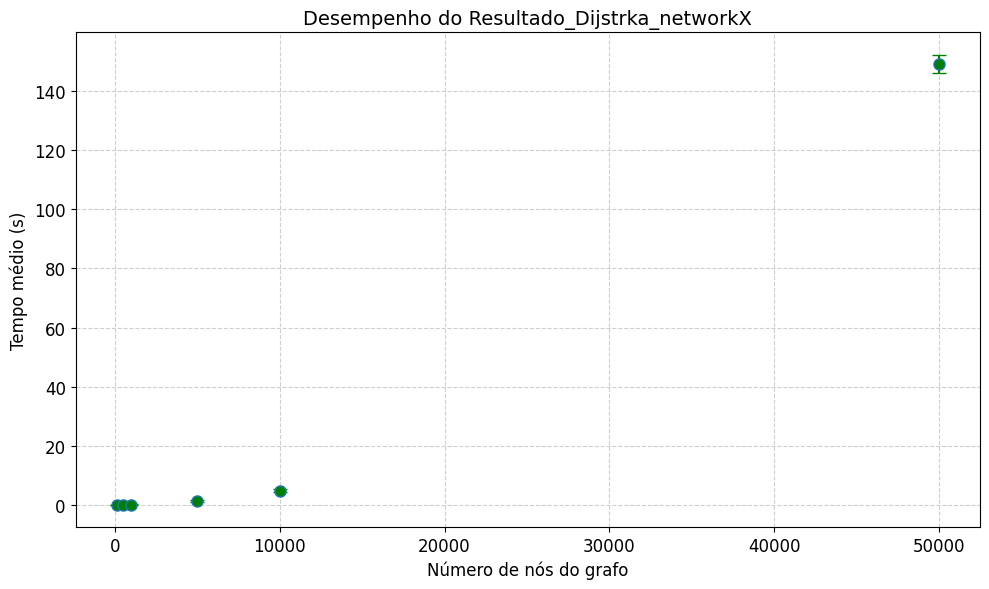

In [42]:
plot_single_algorithm(df_networkx,"Resultado_Dijstrka_networkX","green",save_path="graficos/Resultado_Dijstrka_networkX.png")